In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"No_BCM",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"No_BCM",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_No_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

CPU times: user 8.98 s, sys: 16.7 s, total: 25.6 s
Wall time: 27.9 s


In [2]:
%%time
PC_new_No_BCM = New_PC(Params,PC_No_BCM)
PC_new_Coupled_No_BCM = New_PC(Params,PC_No_BCM)
PC_new_learned_BCM = New_PC_learned(Params,PC_BCM)
PC_new_learned_Coupled_BCM = New_PC_learned(Params,PC_BCM)

CPU times: user 19.9 s, sys: 509 ms, total: 20.4 s
Wall time: 22.2 s


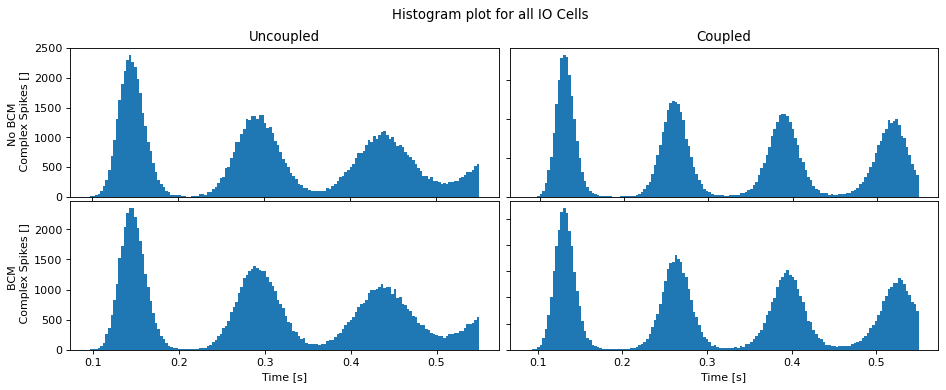

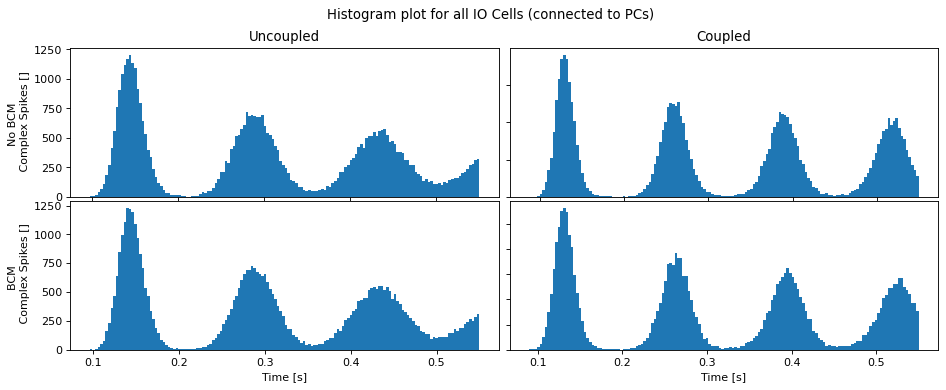

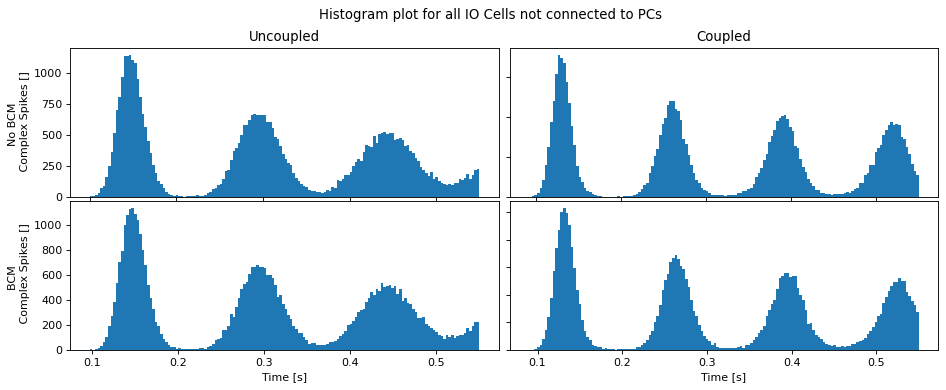

In [3]:
hist_all(step1,Params,Synapses,IO_No_BCM,IO_BCM,IO_Coupled_No_BCM,IO_Coupled_BCM)
hist_con(step1,Params,Synapses,IO_No_BCM,IO_BCM,IO_Coupled_No_BCM,IO_Coupled_BCM)
hist_rest(step1,Params,Synapses,IO_No_BCM,IO_BCM,IO_Coupled_No_BCM,IO_Coupled_BCM)

In [ ]:
raster_plots("BCM","Learned",step1,Params,Synapses,PC_No_BCM,IO_No_BCM,PC_BCM,IO_BCM,PC_Coupled_No_BCM,IO_Coupled_No_BCM,PC_Coupled_BCM,IO_Coupled_BCM)

In [ ]:
raster_plots("","",step1,Params,Synapses,PC_No_BCM,IO_No_BCM,PC_BCM,IO_BCM,PC_Coupled_No_BCM,IO_Coupled_No_BCM,PC_Coupled_BCM,IO_Coupled_BCM)

In [ ]:
raster_plots_both(step1,Params,Synapses,PC_No_BCM,IO_No_BCM,PC_BCM,IO_BCM,PC_Coupled_No_BCM,IO_Coupled_No_BCM,PC_Coupled_BCM,IO_Coupled_BCM)

In [ ]:
hist_rast(step1,Params,Synapses,PC_No_BCM,IO_No_BCM,PC_BCM,IO_BCM,PC_Coupled_No_BCM,IO_Coupled_No_BCM,PC_Coupled_BCM,IO_Coupled_BCM)